<a href="https://colab.research.google.com/github/AlissonValencia/IA_practicas/blob/main/ia_practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

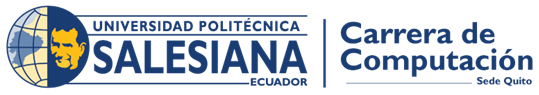






## **Preprocesamiento de Datos**

Nombre: Alisson Valencia

Fecha: 27/04/2026

Materia: Inteligencia Artificial

Práctica: 1

---

***ACTIVIDADES A DESARROLLAR:***

Abrir un Notebook y ejecutar esta celda de verificación antes de iniciar:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
print(" Todas las librerías cargadas correctamente")

 Todas las librerías cargadas correctamente


***FASE 1. Anatomía de un Dataset***

Dataset de estudiantes. Ejecuta el siguiente bloque. No lo modifiques nada todavía, solo léelo con
atención



In [ ]:
import numpy as np
import pandas as pd
datos = {
 "nombre": ["Ana", "Luis", "María", "Carlos", "Sofía", "Diego"],
 "edad": [21, 23, 20, 25, 22, 21],
 "promedio_gpa": [8.9, 7.4, 9.5, 6.1, 8.2, 7.8],
 "horas_estudio": [18, 10, 22, 6, 15, 12],
 "distancia_km": [2.5, 15.0, 0.8, 40.2, 5.1, 8.7],
 "carrera": [
 "Computación","Computación","Redes","Redes","Computación","Redes"],
 "nivel_ingles": [
 "Básico", "Intermedio","Avanzado","Básico","Avanzado","Intermedio"],
 "beca": [1, 0, 1, 0, 1, 0],
 "aprobado": ["Sí", "No", "Sí", "No", "Sí", "No"]
}
df = pd.DataFrame(datos)
print(df)
print(f"\nDimensiones del dataset: {df.shape}")
print(df)
print(f"\nDimensiones del dataset: {df.shape}")

   nombre  edad  promedio_gpa  horas_estudio  distancia_km      carrera  \
0     Ana    21           8.9             18           2.5  Computación   
1    Luis    23           7.4             10          15.0  Computación   
2   María    20           9.5             22           0.8        Redes   
3  Carlos    25           6.1              6          40.2        Redes   
4   Sofía    22           8.2             15           5.1  Computación   
5   Diego    21           7.8             12           8.7        Redes   

  nivel_ingles  beca aprobado  
0       Básico     1       Sí  
1   Intermedio     0       No  
2     Avanzado     1       Sí  
3       Básico     0       No  
4     Avanzado     1       Sí  
5   Intermedio     0       No  

Dimensiones del dataset: (6, 9)
   nombre  edad  promedio_gpa  horas_estudio  distancia_km      carrera  \
0     Ana    21           8.9             18           2.5  Computación   
1    Luis    23           7.4             10          15.0  Computa

---

**Actividad 1.1:** Identifica la estructura. Responde en tu notebook como comentarios o celdas Markdown:

*   **P1.** ¿Cuántas instancias (filas) tiene este dataset? ¿Qué representa cada instancia en el mundo real?

        - El dataset tiene 6 instancias (filas).
        - Cada instancia representa a un estudiante con sus características académicas
          y personales (edad, promedio, horas de estudio, etc.), junto con el resultado de si aprobó o no.

*   **P2.** Lista todos los atributos (columnas). Ahora sepáralos en dos grupos: ¿cuáles actuarían como features y cuál sería el label si tu objetivo fuera predecir si un estudiante aprueba o no?

        - Atributos (columnas): nombre, edad, promedio_gpa, horas_estudio, distancia_km, carrera, nivel_ingles, beca, aprobado.        
        - Features (variables de entrada):edad, promedio_gpa, horas_estudio, distancia_km, carrera, nivel_ingles, beca.
        - Label (variable objetivo): aprobado.



*   **P3.** La columna nombre es un atributo, pero ¿debería ser un feature para un modelo de ML? ¿Por qué sí o por qué no?

        - No, no debería ser un feature, porque el nombre no aporta información relevante para predecir el rendimiento
          académico y es un identificador único.

---

**Actividad 1.2:** Clasifica las variables. Completa la siguiente tabla en tu notebook. Para cada columna, indica su tipo según los criterios estudiados en clase:

In [ ]:
clasificacion = {
 "columna": ["edad", "promedio_gpa", "horas_estudio", "distancia_km",
 "carrera", "nivel_ingles", "beca", "aprobado"],
 "cuantitativa_o_cualitativa": ["?", "?", "?", "?", "?", "?", "?", "?"],
 "discreta_o_continua": ["?", "?", "?", "?", "?", "?", "?", "?"],
 "nominal_u_ordinal": ["NA","NA","NA","NA","?", "?", "?", "?"]
}
df_tipos = pd.DataFrame(clasificacion)
print(df_tipos)

         columna cuantitativa_o_cualitativa discreta_o_continua  \
0           edad                          ?                   ?   
1   promedio_gpa                          ?                   ?   
2  horas_estudio                          ?                   ?   
3   distancia_km                          ?                   ?   
4        carrera                          ?                   ?   
5   nivel_ingles                          ?                   ?   
6           beca                          ?                   ?   
7       aprobado                          ?                   ?   

  nominal_u_ordinal  
0                NA  
1                NA  
2                NA  
3                NA  
4                 ?  
5                 ?  
6                 ?  
7                 ?  


*   **P4.** nivel_ingles tiene los valores Básico, Intermedio y Avanzado. ¿Es nominal u ordinal? ¿En qué te basas para decidirlo? ¿Importa esa distinción a la hora de entrenar un modelo?

        - Es ordinal, ya que, existe un orden por categorías. Y si importa, porque al ser ordinal se puede asiganr valores
          numéricos respetando su orden.



* **P5.** La columna beca solo contiene 0 y 1. ¿Es cuantitativa discreta o cualitativa nominal? Justifica tu respuesta. Pista: piensa en si tiene sentido calcular la media de esos valores.


      Es cualitativa nominal, ya que, 0 y 1 representan una categoría, es decir:
         - 0 = no tiene beca
         - 1 = tiene beca
      Y sí se puede calcular (por ejemplo, promedio = proporción de estudiantes con beca).

    




**Actividad 1.3:** Inspeccionando tipos de datos.

In [ ]:
print("Tipos de datos detectados por pandas:")
print(df.dtypes)
print("\nEstadísticas descriptivas (solo numéricas):")
print(df.describe())

Tipos de datos detectados por pandas:
nombre            object
edad               int64
promedio_gpa     float64
horas_estudio      int64
distancia_km     float64
carrera           object
nivel_ingles      object
beca               int64
aprobado          object
dtype: object

Estadísticas descriptivas (solo numéricas):
            edad  promedio_gpa  horas_estudio  distancia_km      beca
count   6.000000      6.000000       6.000000       6.00000  6.000000
mean   22.000000      7.983333      13.833333      12.05000  0.500000
std     1.788854      1.192337       5.741661      14.68615  0.547723
min    20.000000      6.100000       6.000000       0.80000  0.000000
25%    21.000000      7.500000      10.500000       3.15000  0.000000
50%    21.500000      8.000000      13.500000       6.90000  0.500000
75%    22.750000      8.725000      17.250000      13.42500  1.000000
max    25.000000      9.500000      22.000000      40.20000  1.000000


*   **P6.** ¿Coinciden los tipos que detecta pandas (int64, object, float64) con tu clasificación teórica de la actividad 1.2? Señala al menos un caso donde no coincidan y explica por qué pandas puede estar "equivocado" desde la perspectiva conceptual.

        - En general, no coinciden completamente porque pandas clasifica por formato de almacenamiento, no por significado
          estadístico, es decir, pandas clasifica por tipo de dato técnico (int, float, string), mientras que en análisis
          de datos se clasifica por el rol y significado de la variable.


*   **P7.** Observa las estadísticas descriptivas. ¿Qué columna tiene mayor dispersión (std)? ¿Qué problema podría ocasionar esa diferencia de escala si alimentas este dataset directamente a un algoritmo como KNN?

        - La columna con mayor desviación estándar (std) es distancia_km, porque tiene valores muy separados (ej: 0.8
          hasta 40.2 km), lo que genera alta variabilidad.
        - El algoritmo K-Nearest Neighbors se basa en distancias entre datos, sus problemas serían las variables con mayor
          escala (como distancia_km) dominan el cálculo de distancia y las variables importantes como promedio_gpa o
          horas_estudio quedan "opacada".



***FASE 2. Escalado con NumPy***

En esta fase implementarás los algoritmos desde cero usando solo NumPy. El objetivo es que entiendas exactamente qué hace cada transformación antes de usar una librería que la oculte.

**Actividad 2.1:** Preparando los datos

In [ ]:
# Extraemos SOLO las columnas numéricas continuas para esta fase
columnas_numericas = ["promedio_gpa", "horas_estudio", "distancia_km"]
X = df[columnas_numericas].values.astype(float)

print("Matriz de datos original:")
print(X)
print(f"\nForma: {X.shape}  →  {X.shape[0]} instancias, {X.shape[1]} features")

Matriz de datos original:
[[ 8.9 18.   2.5]
 [ 7.4 10.  15. ]
 [ 9.5 22.   0.8]
 [ 6.1  6.  40.2]
 [ 8.2 15.   5.1]
 [ 7.8 12.   8.7]]

Forma: (6, 3)  →  6 instancias, 3 features


*   **P8.** ¿Por qué excluimos edad y beca de esta matriz aunque también son numéricas? ¿Tiene sentido escalar la columna beca que solo contiene 0 y 1?

        - Porque edad es una variable discreta con un rango pequeño, y en esta fase se priorizan variables continuas donde el
          escalado tiene mayor impacto en el análisis.
        - Porque beca es una variable categórica binaria (0/1), no representa una magnitud continua sino una categoría.
        - No tiene sentido porque, escalarla no aporta información adicional y puede distorsionar su interpretación como variable
          categórica.


**Actividad 2.2:** Normalización Min-Max

In [ ]:
def min_max_manual(X):
  """
  Normalización Min-Max: transforma cada columna al rango [0, 1]
  Fórmula: x' = (x - min) / (max - min)
  """
  X_min = X.min(axis=0)   # mínimo por columna
  X_max = X.max(axis=0)   # máximo por columna
  X_norm = (X - X_min) / (X_max - X_min)
  return X_norm, X_min, X_max

X_minmax, mins, maxs = min_max_manual(X)

print("=== RESULTADO MIN-MAX ===")
print(f"{'Feature':<18} {'Min original':>14} {'Max original':>14}")
print("-" * 48)
for i, col in enumerate(columnas_numericas):
  print(f"{col:<18} {mins[i]:>14.2f} {maxs[i]:>14.2f}")

print("\nDatos normalizados (Min-Max):")
df_minmax = pd.DataFrame(X_minmax, columns=[c+"_mm" for c in columnas_numericas])
print(df_minmax.round(4))

=== RESULTADO MIN-MAX ===
Feature              Min original   Max original
------------------------------------------------
promedio_gpa                 6.10           9.50
horas_estudio                6.00          22.00
distancia_km                 0.80          40.20

Datos normalizados (Min-Max):
   promedio_gpa_mm  horas_estudio_mm  distancia_km_mm
0           0.8235            0.7500           0.0431
1           0.3824            0.2500           0.3604
2           1.0000            1.0000           0.0000
3           0.0000            0.0000           1.0000
4           0.6176            0.5625           0.1091
5           0.5000            0.3750           0.2005


*   **P9.** Después de aplicar Min-Max, ¿cuál es el valor mínimo y máximo que puede tomar cualquier columna? Verifica que tus resultados lo confirmen. ¿Qué representa un valor transformado de 0.0? ¿Y uno de 1.0?
        
        - El mínimo es 0.0 y el máximo es 1.0.
             0.0 → representa el valor mínimo original de esa columna.
             1.0 → representa el valor máximo original de esa columna.



*   **P10.** Fíjate en la columna distancia_km. Carlos vive a 40.2 km, que es un valor extremo. Ahora imagina que llega un nuevo estudiante que vive a 80 km. Si agregas ese dato y vuelves a normalizar, ¿qué le pasará al valor transformado de todos los demás estudiantes? ¿Es eso un problema? ¿Por qué?

        - Si aparece un nuevo estudiante, todos los valores normalizados disminuirán (se comprimen), porque el nuevo máximo
          aumenta.
        - Sí es un problema, porque la normalización Min-Max es sensible a valores extremos, y un nuevo dato puede cambiar
          toda la escala, afectando la consistencia del modelo.




**Actividad 2.3:** Estandarización Z-Score

In [ ]:
def zscore_manual(X):
  """
  Z-Score: transforma cada columna a media=0 y desv.est.=1
  Fórmula: z = (x - media) / desviacion_estandar
  """
  media = X.mean(axis=0)
  std   = X.std(axis=0)       # desviación estándar de la población
  X_z   = (X - media) / std
  return X_z, media, std

X_zscore, medias, stds = zscore_manual(X)

print("=== RESULTADO Z-SCORE ===")
print(f"{'Feature':<18} {'Media':>10} {'Desv.Est.':>12}")
print("-" * 42)
for i, col in enumerate(columnas_numericas):
  print(f"{col:<18} {medias[i]:>10.3f} {stds[i]:>12.3f}")

print("\nDatos estandarizados (Z-Score):")
df_z = pd.DataFrame(X_zscore, columns=[c+"_z" for c in columnas_numericas])
print(df_z.round(4))

=== RESULTADO Z-SCORE ===
Feature                 Media    Desv.Est.
------------------------------------------
promedio_gpa            7.983        1.088
horas_estudio          13.833        5.241
distancia_km           12.050       13.407

Datos estandarizados (Z-Score):
   promedio_gpa_z  horas_estudio_z  distancia_km_z
0          0.8422           0.7950         -0.7123
1         -0.5359          -0.7314          0.2200
2          1.3934           1.5581         -0.8391
3         -1.7303          -1.4945          2.0997
4          0.1991           0.2226         -0.5184
5         -0.1684          -0.3498         -0.2499


*   **P11.** Después de aplicar Min-Max, ¿cuál es el valor mínimo y máximo que puede tomar cualquier columna? Verifica que tus resultados lo confirmen. ¿Qué representa un valor transformado de 0.0? ¿Y uno de 1.0?
        
        - El mínimo es 0.0 y el máximo es 1.0.
             0.0 → representa el valor mínimo original de esa columna.
             1.0 → representa el valor máximo original de esa columna.



*   **P12.** Carlos tiene horas_estudio = 6. Después del Z-Score, su valor transformado es negativo. ¿Qué significa eso en términos estadísticos? ¿Significa que Carlos estudia "mal"? ¿Qué dice ese valor sobre su posición relativa al grupo?

        - Significa que su valor (horas de estudio = 6) está por debajo de la media del grupo.
        - No estudia "mal", solo indica que estudia menos que el promedio, no evalúa calidad.
        - Dice que está por debajo del promedio del grupo, y mientras más negativo sea, más lejos está de la media.


*   **P13.** Compara los valores de Carlos y Sofía para distancia_km después de Min-Max y después de Z-Score. ¿Cuál de las dos transformaciones te parece más informativa sobre la "rareza" de vivir a 40 km? Argumenta.

        - Min-Max muestra posición en el rango, pero no qué tan extremo es, como Carlos (40.2 km) tendrá valor cercano a 1,
          Sofía (~5.1 km) cercano a 0. Y Z-Score mide cuántas desviaciones estándar se aleja cada uno, es decir, Carlos tendrá
          un valor muy alto positivo, Sofía cercano a la media.
        - A mi parecer la más informativa es Z-Score, porque indica qué tan lejos está un valor respecto a la media, permitiendo
          identificar valores atípicos (como vivir a 40 km), no solo su posición dentro del rango.

**Actividad 2.4:** Comparación visual de las tres columnas

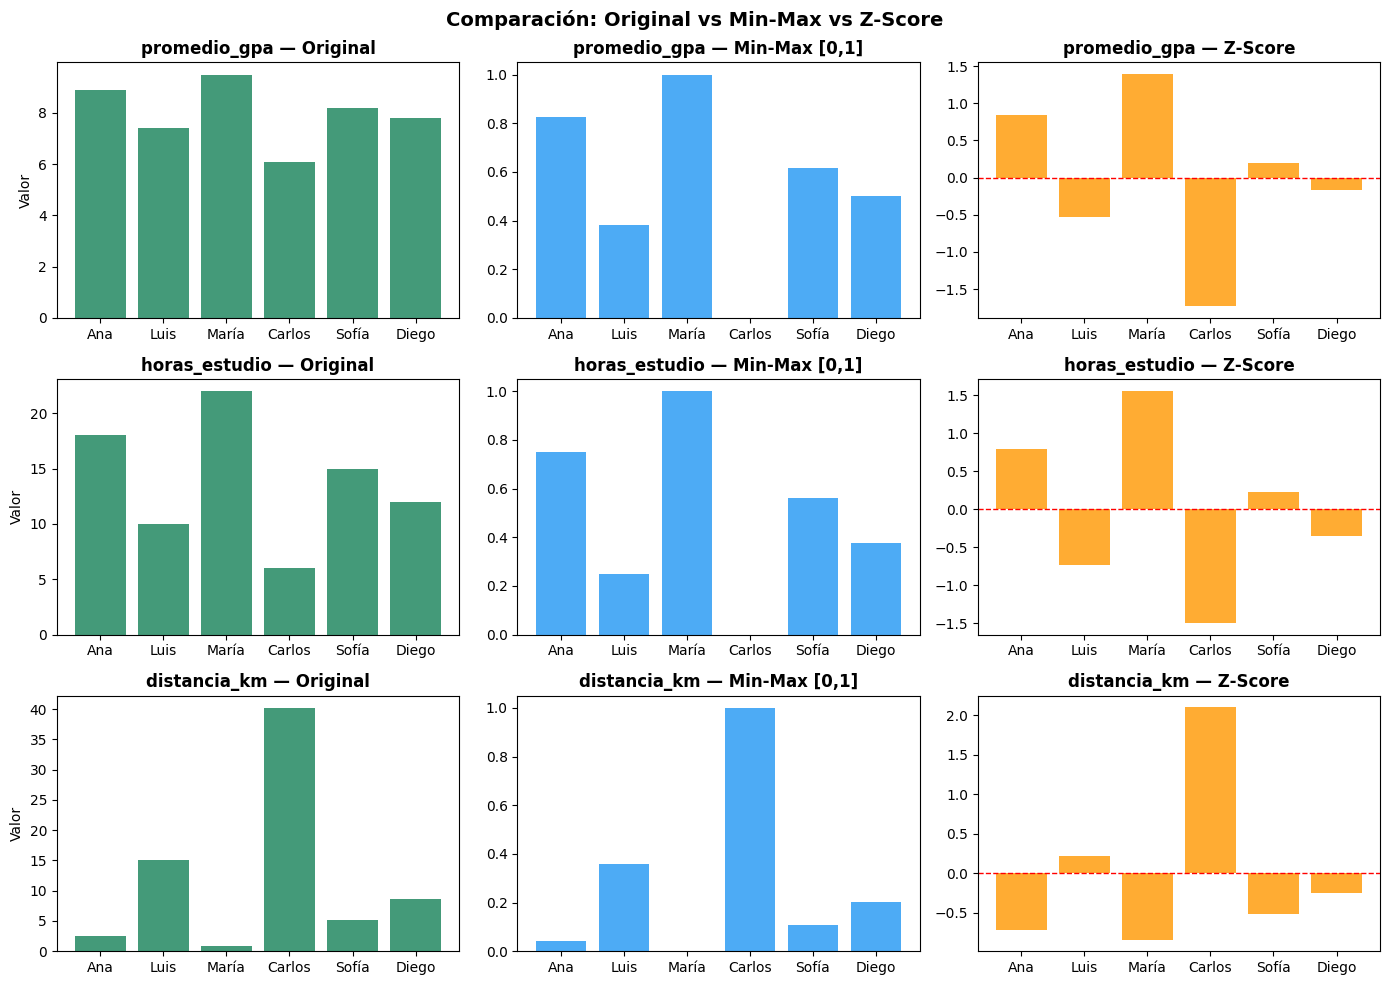

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
nombres = df["nombre"].values

for i, col in enumerate(columnas_numericas):
  # Original
  axes[i, 0].bar(nombres, X[:, i], color="#158158", alpha=0.8)
  axes[i, 0].set_title(f"{col} — Original", fontweight='bold')
  axes[i, 0].set_ylabel("Valor")

  # Min-Max
  axes[i, 1].bar(nombres, X_minmax[:, i], color="#2196F3", alpha=0.8)
  axes[i, 1].set_title(f"{col} — Min-Max [0,1]", fontweight='bold')

  # Z-Score
  axes[i, 2].bar(nombres, X_zscore[:, i], color="#FF9800", alpha=0.8)
  axes[i, 2].axhline(0, color='red', linestyle='--', linewidth=1)
  axes[i, 2].set_title(f"{col} — Z-Score", fontweight='bold')

plt.suptitle("Comparación: Original vs Min-Max vs Z-Score",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparacion_escalado.png", dpi=100)
plt.show()

*   **P14.** Observa la gráfica de distancia_km. Las proporciones relativas entre estudiantes, ¿se mantienen igual en las tres versiones? ¿Qué es lo que realmente cambia entre Original, Min-Max y Z-Score?

        - Sí, las relaciones entre los estudiantes se conservan en las tres versiones, el que tenía mayor valor sigue siendo el
          mayor y el orden relativo no cambia.

        - Original muestra los valores reales (en km), con su escala original, en Min-Max cambia la escala al rango [0, 1] se
          mantiene la proporción, pero todo se “comprime” dentro de ese rango y para Z-Score centra los datos en media = 0 y los
          mide en desviaciones estándar, permite ver qué tan lejos está cada valor del promedio (valores negativos y positivos).



**Actividad 2.5:** Simulando un outlier extremo

In [36]:
# Añadimos un estudiante con una distancia extrema
X_con_outlier = np.vstack([X, [8.5, 14, 120.0]])  # 120 km

# Aplicamos Min-Max sobre los datos CON outlier
X_mm_con_outlier, _, _ = min_max_manual(X_con_outlier)

# Aplicamos Z-Score sobre los datos CON outlier
X_z_con_outlier, _, _ = zscore_manual(X_con_outlier)

print("=== Columna distancia_km con outlier (120 km) ===")
print(f"\n{'Estudiante':<10} {'Original':>10} {'Min-Max':>10} {'Z-Score':>10}")
print("-" * 44)
nombres_ext = list(nombres) + ["Nuevo"]
for j in range(len(nombres_ext)):
  print(f"{nombres_ext[j]:<10} {X_con_outlier[j,2]:>10.1f} "
        f"{X_mm_con_outlier[j,2]:>10.4f} {X_z_con_outlier[j,2]:>10.4f}")

=== Columna distancia_km con outlier (120 km) ===

Estudiante   Original    Min-Max    Z-Score
--------------------------------------------
Ana               2.5     0.0143    -0.6280
Luis             15.0     0.1191    -0.3137
María             0.8     0.0000    -0.6708
Carlos           40.2     0.3305     0.3201
Sofía             5.1     0.0361    -0.5626
Diego             8.7     0.0663    -0.4721
Nuevo           120.0     1.0000     2.3271


*   **P15.** Observa lo que ocurre con los valores de los otros estudiantes en Min-Max después de agregar el outlier de 120 km. ¿Qué problema genera esto? ¿Por qué Z-Score es más robusto ante este caso? ¿Existe alguna técnica mejor aún?

        - Los valores de los otros estudiantes en distancia_km se comprimen fuertemente hacia 0, se pierden diferenciación entre
          ellos y los valores que antes eran distintos ahora quedan muy similares.
        - Se distorsiona la escala de la variable, se pierde información útil sobre las diferencias reales entre estudiantes y el
          modelo puede volverse menos preciso porque “ve” los datos casi iguales.
        - Porque no depende directamente del mínimo y máximo, ésta usa media y desviación estándar, por lo que el impacto del
          outlier es menor en comparación con Min-Max y los demás valores no se comprimen tanto.
        - Sí existe una opción más robusta es el Robust Scaling, basado en Mediana y Rango intercuartílico (IQR), éste es
          mucho menos sensible a valores extremos (outliers).



***FASE 3. Dataset real con Pandas: Palmer Penguins***

Ahora trabajarás con un dataset real de Hugging Face. El dataset Palmer Penguins, creado originalmente como paquete de R, fue diseñado para reemplazar al famoso Iris dataset en tareas de exploración y visualización de datos.

In [37]:
import pandas as pd

# Cargamos el dataset directamente desde Hugging Face
url = "https://huggingface.co/datasets/SIH/palmer-penguins/resolve/main/penguins.csv"
df_penguins = pd.read_csv(url)

print("=== PRIMERA VISTA DEL DATASET ===")
print(df_penguins.head(8))
print(f"\nDimensiones: {df_penguins.shape}")
print(f"\nColumnas: {list(df_penguins.columns)}")

=== PRIMERA VISTA DEL DATASET ===
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6  Adelie  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  
5       3650.0    male  2007  
6       3625.0  female  2007  
7       4675.0    male  2007  

Dimensiones: (344, 

**Actividad 3.1:** Exploración inicial obligatoria

In [38]:
print("\n=== TIPOS DE DATOS ===")
print(df_penguins.dtypes)

print("\n=== VALORES NULOS ===")
print(df_penguins.isnull().sum())

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df_penguins.describe())

print("\n=== VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS ===")
for col in df_penguins.select_dtypes(include='object').columns:
  print(f"{col}: {df_penguins[col].unique()}")


=== TIPOS DE DATOS ===
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

=== VALORES NULOS ===
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.30000

*   **P16.** Identifica para este dataset: ¿cuántas instancias tiene? ¿Cuáles son las features numéricas? ¿Cuál sería el label más lógico para una tarea de clasificación?

        - Tiene 344 instancias (filas).
        - Son: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g.
        - Sería species, ya que, representa la especie del pingüino (Adelie, Chinstrap, Gentoo), lo que encaja naturalmente
          en un problema de clasificación.



*   **P17.** ¿Hay valores nulos? ¿En qué columnas? ¿Por qué es importante tratar los valores nulos antes de aplicar escalado? ¿Qué pasaría si escalas con NaN presentes?

        - Sí, hay valores nulos, principalmente en columnas como: bill_length_mm, bill_depth_mm, flipper_length_mm,
          body_mass_g, sex.
        - Porque los algoritmos de escalado (Min-Max, Z-Score) no pueden operar correctamente con valores faltantes,
          y también necesitan datos completos para calcular mínimos, máximos, medias y desviaciones.
        - El resultado también contendrá NaN, también se propagan errores en los cálculos y puede provocar fallos en
          modelos de Machine Learning o resultados inválidos.



**Actividad 3.2:** Clasificación de variables del dataset

*   **P18.** Para cada columna de df_penguins, clasifica su tipo completo. Presta especial atención a sex e island. ¿Son las dos nominales? ¿Cambiaría la respuesta si ordenamos las islas por temperatura promedio del océano?

        - Columnas y tipo:
             * species → Cualitativa nominal (categoría sin orden; posible label)
             * island → Cualitativa nominal
             * bill_length_mm → Cuantitativa continua
             * bill_depth_mm → Cuantitativa continua
             * flipper_length_mm → Cuantitativa continua
             * body_mass_g → Cuantitativa continua
             * sex → Cualitativa nominal (binaria)
           Sí, sex e island ambas son nominales porque no tienen un orden intrínseco y son etiquetas (categorías).
        - Sí cambiaría, ya que, en ese caso podría tratarse como ordinal, porque se introduce un criterio de orden externo (temperatura promedio) y las categorías pasan a tener jerarquía.



**Actividad 3.3:** Preprocesamiento y escalado

In [39]:
# Paso 1: Eliminar filas con valores nulos
df_clean = df_penguins.dropna()
print(f"Filas originales: {len(df_penguins)}  →  Filas limpias: {len(df_clean)}")

# Paso 2: Seleccionar features numéricas
features_num = ["bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g"]
X_penguins = df_clean[features_num].values

print("\nEstadísticas ANTES del escalado:")
print(pd.DataFrame(X_penguins, columns=features_num).describe().round(2))

Filas originales: 344  →  Filas limpias: 333

Estadísticas ANTES del escalado:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


*   **P19.** Mira las escalas de body_mass_g (en gramos, ~3500–6000) vs bill_depth_mm (en mm, ~13–21). Si entrenas un modelo con estos datos sin escalar, ¿cuál variable tendrá más peso en el cálculo de distancia? ¿Es eso justo biológicamente?

        - body_mass_g, porque tiene valores mucho más grandes (~3500–6000) que bill_depth_mm (~13–21), en algoritmos basados en
          distancia, los valores grandes dominan el cálculo.
        - No es justo biológicamente, ya que, el peso no necesariamente es más importante que otras características como tamaño
          del pico o aleta. La diferencia es solo de unidad de medida, no de relevancia real.



**Actividad 3.4:** Análisis de distribuciones

In [40]:
# Paso 3: Aplicar Min-Max
mm = MinMaxScaler()
X_mm = mm.fit_transform(X_penguins)

# Paso 4: Aplicar Z-Score
zs = StandardScaler()
X_zs = zs.fit_transform(X_penguins)

# Paso 5: Comparar estadísticas
print("\n--- Min-Max ---")
print(pd.DataFrame(X_mm, columns=features_num).describe().round(4))

print("\n--- Z-Score ---")
print(pd.DataFrame(X_zs, columns=features_num).describe().round(4))


--- Min-Max ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count        333.0000       333.0000           333.0000     333.0000
mean           0.4325         0.4839             0.4910       0.4186
std            0.1989         0.2344             0.2376       0.2237
min            0.0000         0.0000             0.0000       0.0000
25%            0.2691         0.2976             0.3051       0.2361
50%            0.4509         0.5000             0.4237       0.3750
75%            0.6000         0.6667             0.6949       0.5764
max            1.0000         1.0000             1.0000       1.0000

--- Z-Score ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count        333.0000       333.0000           333.0000     333.0000
mean          -0.0000        -0.0000             0.0000      -0.0000
std            1.0015         1.0015             1.0015       1.0015
min           -2.1780        -2.0673            -2.0699      -1.8744


*   **P20.** ¿El escalado cambia la forma de la distribución (histograma) o solo la escala de los ejes? ¿Por qué importa esa respuesta cuando evaluamos normalidad de los datos?

        - Solo cambia la escala de los ejes, no la forma de la distribución.
        - Porque la normalidad debe evaluarse antes o independientemente del escalado.



*   **P21.** Observa la distribución de body_mass_g. ¿Se parece a una campana de Gauss (distribución normal) o tiene alguna asimetría? ¿Afecta eso a la elección entre Min-Max y Z-Score?

        - No es perfectamente normal, suele mostrar ligera asimetría (puede estar sesgada) y esto ocurre porque hay diferencias
          claras entre especies.
        - Si, porque en Z-Score funciona mejor cuando los datos se aproximan a una distribución normal y en Min-Max no asume
          ninguna forma de distribución.



***FASE 4: HuggingFace + sklearn***

En la fase anterior implementaste Min-Max y Z-Score desde cero con NumPy. Ahora vas a reproducir exactamente los mismos resultados usando sklearn, y añadirás un tercer método que no puedes implementar tan fácilmente a mano: el Robust Scaler. El dataset sigue siendo Palmer Penguins, que ya conoces.

**Actividad 4.1:** Retornando al dataset limpio

Asegúrate de tener el DataFrame df_clean y las columnas features_num de la Fase 3. Si reiniciaste el kernel, ejecuta esto:

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

url = "https://huggingface.co/datasets/SIH/palmer-penguins/resolve/main/penguins.csv"
df_penguins = pd.read_csv(url)
df_clean = df_penguins.dropna()

features_num = ["bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g"]

X = df_clean[features_num].values
print(f"Dataset listo: {X.shape[0]} instancias, {X.shape[1]} features")
print(f"\nEstadísticas originales:")
print(pd.DataFrame(X, columns=features_num).describe().round(2))

Dataset listo: 333 instancias, 4 features

Estadísticas originales:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


*   **P22.** Antes de continuar: ¿cuál de las cuatro features tiene mayor rango (max − min)? ¿Cuál tiene menor rango? Calcula ambos valores con código y anótalos, los vas a necesitar para comparar después.


In [42]:
rangos = df_clean[features_num].max() - df_clean[features_num].min()
print(rangos)

bill_length_mm         27.5
bill_depth_mm           8.4
flipper_length_mm      59.0
body_mass_g          3600.0
dtype: float64


        - Mayor rango: body_mass_g → ~2850 g, tiene la mayor variabilidad absoluta, por eso domina sin escalado.
        - Menor rango: bill_depth_mm → ~8 mm, tiene la menor variación, por lo que su impacto es menor en distancias.

**Actividad 4.2:** División train/test. Antes de escalar, el dataset debe dividirse. Este orden no es opcional.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.2,     # 80% entrenamiento, 20% prueba
    random_state=42    # fija la aleatoriedad para reproducibilidad
)

print(f"Train: {X_train.shape}  →  {X_train.shape[0]} pingüinos")
print(f"Test:  {X_test.shape}   →  {X_test.shape[0]} pingüinos")

Train: (266, 4)  →  266 pingüinos
Test:  (67, 4)   →  67 pingüinos


*   **P23.** ¿Por qué se divide el dataset antes de aplicar el escalado y no después? Piensa en qué información usaría el scaler si lo aplicaras primero sobre todo el dataset. ¿Qué datos del test estarías "filtrando" al proceso de entrenamiento? Esto se llama data leakage; explícalo con tus propias palabras.

        - El dataset se divide antes del escalado para evitar que el modelo tenga acceso a información que no debería conocer
          durante el entrenamiento.
        - Primero se divide el dataset, luego se ajusta el scaler solo con datos de entrenamiento, y finalmente se aplica a
          train y test. Así se evita el data leakage y se obtiene una evaluación confiable.



**Actividad 4.3:** Aplicando los tres escaladores El patrón de uso es siempre el mismo:

      • fit_transform(X_train) → aprende los parámetros del train y lo transforma
  
      • transform(X_test) → aplica los mismos parámetros aprendidos al test, sin recalcularlos

In [44]:
# Instanciar los tres escaladores
mm_scaler  = MinMaxScaler()
zs_scaler  = StandardScaler()
rb_scaler  = RobustScaler()

# Aplicar a train: fit + transform
X_train_mm = mm_scaler.fit_transform(X_train)
X_train_zs = zs_scaler.fit_transform(X_train)
X_train_rb = rb_scaler.fit_transform(X_train)

# Aplicar a test: solo transform (NO fit)
X_test_mm  = mm_scaler.transform(X_test)
X_test_zs  = zs_scaler.transform(X_test)
X_test_rb  = rb_scaler.transform(X_test)

print("Parámetros aprendidos por MinMaxScaler (sobre train):")
print(f"  Mínimos:  {mm_scaler.data_min_.round(2)}")
print(f"  Máximos:  {mm_scaler.data_max_.round(2)}")

print("\nParámetros aprendidos por StandardScaler (sobre train):")
print(f"  Medias:   {zs_scaler.mean_.round(2)}")
print(f"  Std:      {zs_scaler.scale_.round(2)}")

print("\nParámetros aprendidos por RobustScaler (sobre train):")
print(f"  Medianas: {rb_scaler.center_.round(2)}")
print(f"  IQR:      {rb_scaler.scale_.round(2)}")

Parámetros aprendidos por MinMaxScaler (sobre train):
  Mínimos:  [  32.1   13.1  172.  2700. ]
  Máximos:  [  59.6   21.5  231.  6050. ]

Parámetros aprendidos por StandardScaler (sobre train):
  Medias:   [  44.08   17.07  201.41 4232.61]
  Std:      [  5.41   1.97  14.24 809.57]

Parámetros aprendidos por RobustScaler (sobre train):
  Medianas: [  44.9   17.2  197.  4100. ]
  IQR:      [   8.9    3.2   24.  1200. ]


*   **P24.** Compara los parámetros que aprendió MinMaxScaler (mínimos y máximos) con los que calculaste manualmente en la Fase 2 con NumPy. ¿Son exactamente iguales o hay alguna diferencia pequeña? ¿A qué se debe si la hay?

        - No necesariamente son exactamente iguales, aunque deberían ser muy cercanos.
        - Se debe a que en la Fase 2 se usó todo el dataset, mientras que aquí el scaler usa solo X_train. El conjunto de
          entrenamiento es una muestra (80%), por lo que sus mínimos y máximos pueden variar ligeramente y también pueden
          existir pequeñas diferencias por precisión numérica (redondeo).



*   **P25.** El RobustScaler aprende la mediana y el IQR de cada columna, no la media ni el std. Calcula manualmente la mediana y el IQR de body_mass_g en el train con NumPy y verifica que coincidan con rb_scaler.center_[3] y rb_scaler.scale_[3].

In [45]:
# Seleccionamos la columna body_mass_g del train
body_mass_train = X_train[:, 3]

# Cálculo manual con NumPy
mediana = np.median(body_mass_train)
q1 = np.percentile(body_mass_train, 25)
q3 = np.percentile(body_mass_train, 75)
iqr = q3 - q1

print("Cálculo manual:")
print(f"Mediana: {mediana:.2f}")
print(f"IQR:     {iqr:.2f}")

print("\nRobustScaler:")
print(f"Mediana: {rb_scaler.center_[3]:.2f}")
print(f"IQR:     {rb_scaler.scale_[3]:.2f}")

Cálculo manual:
Mediana: 4100.00
IQR:     1200.00

RobustScaler:
Mediana: 4100.00
IQR:     1200.00


**RESULTADOS OBTENIDOS:**

**Fase 1.** Al ejecutar el código se obtendrá una tabla con 6 filas y 9 columnas, seguida de las estadísticas descriptivas. Se espera identificar claramente qué columnas son features y cuál es el label, y detectar al menos un caso donde el tipo reportado por pandas no coincide con la clasificación teórica.

**Fase 2.** Se obtendrán tres versiones de la misma matriz de datos: original, normalizada en [0, 1] y estandarizada con media≈0 y std≈1. La gráfica mostrará que las proporciones entre estudiantes se conservan en las tres versiones. Al simular el outlier de 120 km, se observará que los valores Min-Max de los demás estudiantes se comprimen notoriamente, efecto que Z-Score atenúa.

**Fase 3.** Se cargará un dataset real de 344 instancias con valores nulos en algunas columnas. Tras la limpieza quedarán 333 filas. Los histogramas mostrarán que la forma de cada distribución es idéntica antes y después del escalado; solo cambian los valores del eje horizontal.

**Fase 4.** Se verificará que fit_transform sobre el train y transform sobre el test producen conjuntos correctamente escalados con los tres métodos. Al comparar los parámetros internos de cada scaler con los cálculos manuales de la Fase 2, los valores deben coincidir.

**CONCLUSIONES:**


1. El tipo y naturaleza de las variables determinan el preprocesamiento; no todas las variables deben tratarse igual. Variables continuas requieren escalado, mientras que variables categóricas (como beca, sexo o carrera) deben manejarse con codificación adecuada. Comprender la diferencia entre cuantitativas y cualitativas evita errores en el modelado.
2. El escalado es esencial para modelos basados en distancia; las diferencias de magnitud (por ejemplo, entre body_mass_g y bill_depth_mm) pueden sesgar los resultados si no se escalan. Métodos como Min-Max, Z-Score y RobustScaler permiten equilibrar la influencia de cada variable, siendo este último más resistente a valores extremos.
3. El orden correcto del preprocesamiento evita errores graves (data leakage) y dividir el dataset en entrenamiento y prueba antes de aplicar transformaciones es fundamental. Aplicar escalado sobre todo el dataset introduce información del test en el entrenamiento, generando evaluaciones poco confiables y modelos que no generalizan bien.



**REFERENCIAS:**


    [1] Bhujabal, A. (2023, septiembre 27). Data standardization in ML. Medium.
        https://ansumanbhujabal.medium.com/data-standardization-in-ml-2418fd7708de
    
    [2] Brenndoerfer, M. (2025). Normalization: Complete guide to feature scaling with Min-Max implementation.
        https://mbrenndoerfer.com/writing/normalization-feature-scaling-min-max-machinelearning-guide
    
    [3] Feature scaling, Min-Max and Z-Score normalization. (s.f.). Jisoo Lee. Recuperado el 22 de abril de 2026,
        de https://jisooleeworks.github.io/blog-site/2022/09/09/feature-scaling-min-max-z-score.html
    
    [4] Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological sexual dimorphism and environmental variability within
        a community of Antarctic penguins (Genus Pygoscelis). PLOS ONE, 9(3), e90081. https://doi.org/10.1371/journal.pone.0090081
    
    [5] Normalization: Min-Max and Z-Score normalization. (s.f.). Codecademy. Recuperado el 22 de abril de 2026,
        de https://www.codecademy.com/article/min-max-zscore-normalization
    
    [6] Olawale, A. (2025, octubre 22). Scaling and normalizing data. Medium.
        https://medium.com/@Adekola_Olawale/scaling-and-normalizing-data-6376df7cc4b7
    
    [7] Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer,
        P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay,
        É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.
        https://jmlr.org/papers/v12/pedregosa11a.html
    
    [8] scikit-learn developers. (2024). Preprocessing data — scikit-learn 1.4 documentation.
        https://scikitlearn.org/stable/modules/preprocessing.html
    
    [9] SIH. (2024). Palmer penguins [Dataset]. Hugging Face. https://huggingface.co/datasets/SIH/palmer-penguins
    
    [10] Statistics Day 4: Z-Score vs Min-Max normalization — Making data fair for ML models. (2025, noviembre 15).DEV Community.
         https://dev.to/brains_behind_bots/statistics-day-4-z-score-vs-minmax-normalization-making-data-fair-for-ml-models-1plc
    
    [11] What is standardization in machine learning. (s.f.). GeeksforGeeks. Recuperado el 22 de abril de 2026,
         de https://www.geeksforgeeks.org/machine-learning/what-is-standardization-in-machinelearning/
    
    [12] Z-Score normalization: Definition and examples. (s.f.). GeeksforGeeks. Recuperado el 22 de abril de 2026,
         de https://www.geeksforgeeks.org/data-analysis/z-score-normalization-definition-andexamples/  







